# Recomputing Concordance Indices

This notebook sweeps every stored experiment under `Results/` and recomputes the concordance index (CI) using the saved model checkpoints. For each `(agent, dataset, seed)` combination we:
1. load the original configuration and instantiate the correct agent,
2. restore the trained parameters from `model.pt`,
3. rebuild the deterministic train/test split, and
4. evaluate the model again to obtain a fresh CI (and Brier score).

The table at the end compares the recomputed metrics with the values stored during the original runs.

In [1]:
import json
import pickle
from pathlib import Path

import pandas as pd
import yaml
from tqdm.auto import tqdm

import sys
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from baseline_cox import SA
from lambda_cox import LambdaSA
from deep_lambda_cox import DeepLambdaSA


/Users/mariana/.Envs/jax/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:

RESULTS_ROOT = PROJECT_ROOT / "Results"
TEST_SIZE = 0.2  # Train/test split used during training

AGENT_MAP = {
    "SA": SA,
    "LambdaSA": LambdaSA,
    "DeepLambdaSA": DeepLambdaSA,
}

records = []
failures = []

# datasets_of_interest = {"nasa", "churn_lastfm_months", "mimic"}
datasets_of_interest = {"mimic"}
seed_dirs = [
    p
    for p in RESULTS_ROOT.glob("*/**/seed_*")
    if len(p.relative_to(RESULTS_ROOT).parts) >= 7
    and p.relative_to(RESULTS_ROOT).parts[1] in datasets_of_interest
    and p.name.split('_')[-1].isdigit()
    and 0 <= int(p.name.split('_')[-1]) <= 10
]
seed_dirs.sort()
for seed_dir in tqdm(seed_dirs, desc="Seeds"):
    relative = seed_dir.relative_to(RESULTS_ROOT)
    parts = relative.parts
    if len(parts) < 7:
        failures.append({"path": str(seed_dir), "reason": "Unexpected directory depth"})
        continue

    agent_name, dataset_name, arch_name, lambda_dir, landmark_dir, exp_name, seed_name = parts[:7]
    config_path = seed_dir.parent / "config.yaml"
    model_path = seed_dir / "model.pt"
    prev_results_path = seed_dir / "results.json"

    if agent_name not in AGENT_MAP:
        failures.append({"path": str(seed_dir), "reason": f"Unknown agent {agent_name}"})
        continue
    if not config_path.exists():
        failures.append({"path": str(seed_dir), "reason": "Missing config.yaml"})
        continue
    if not model_path.exists():
        failures.append({"path": str(seed_dir), "reason": "Missing model.pt"})
        continue

    lambda_token = lambda_dir.split("_", 1)[1] if "_" in lambda_dir else None
    try:
        lambda_value = float(lambda_token) if lambda_token not in (None, "None") else None
    except ValueError:
        lambda_value = None

    landmark_token = landmark_dir.split("_", 1)[1] if "_" in landmark_dir else "False"
    landmark_value = True if landmark_token.lower() == "true" else False

    try:
        seed_value = int(seed_name.split("_")[-1])
    except ValueError:
        failures.append({"path": str(seed_dir), "reason": f"Could not parse seed from {seed_name}"})
        continue

    try:
        with open(config_path, "r") as fh:
            config_dict = yaml.safe_load(fh)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to load config: {exc}"})
        continue

    if lambda_value is not None:
        config_dict['lambda_'] = lambda_value
    config_dict['landmark'] = bool(landmark_value)

    AgentCls = AGENT_MAP[agent_name]
    try:
        agent = AgentCls(config_dict, seed_value)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to instantiate agent: {exc}"})
        continue

    try:
        with open(model_path, "rb") as fh:
            params = pickle.load(fh)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to load params: {exc}"})
        continue

    try:
        if agent_name == "DeepLambdaSA":
            agent.state = agent.state.replace(params=params, tgt_params=params)
        else:
            agent.state = agent.state.replace(params=params)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to restore parameters: {exc}"})
        continue

    try:
        _, test_gen = agent.get_train_test(test_size=TEST_SIZE)
        bs_new, ci_new = agent.eval(test_gen)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Evaluation failed: {exc}"})
        continue

    prev_ci = prev_bs = None
    if prev_results_path.exists():
        try:
            with open(prev_results_path, "r") as fh:
                previous = json.load(fh)
            prev_ci = previous.get("ci")
            prev_bs = previous.get("bs")
        except Exception:
            prev_ci = prev_bs = None

    records.append({
        "agent": agent_name,
        "dataset": dataset_name,
        "architecture": arch_name,
        "lambda": lambda_value,
        "landmark": landmark_value,
        "experiment": exp_name,
        "seed": seed_value,
        "ci_new": float(ci_new),
        "ibs_new": float(bs_new),
        "ci_original": prev_ci,
        "ibs_original": prev_bs,
        "model_path": str(model_path),
    })

results_df = pd.DataFrame(records)
if not results_df.empty:
    results_df = results_df.sort_values(["agent", "dataset", "architecture", "lambda", "landmark", "experiment", "seed"]).reset_index(drop=True)





Seeds: 100%|██████████| 55/55 [00:00<00:00, 661.22it/s]


In [10]:
print(f"Recomputed entries: {len(results_df)}")
print(f"Failures: {len(failures)}")
if failures:
    display(pd.DataFrame(failures))

results_df.head()

if not results_df.empty:
    pivot_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg = (
        results_df
        .groupby(pivot_cols)[['ci_new', 'ibs_new']]
        .agg(['mean', 'std'])
        .sort_index()
    )
    display(agg)


Recomputed entries: 0
Failures: 55


,path,reason
0,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
1,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
2,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
3,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
4,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
5,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
6,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
7,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
8,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...
9,/Users/mariana/Documents/col/lts4/survan/Resul...,Failed to instantiate agent: type of dataset n...


In [12]:
failures

[{'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_0',
  'reason': 'Failed to instantiate agent: type of dataset not found.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_1',
  'reason': 'Failed to instantiate agent: type of dataset not found.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_10',
  'reason': 'Failed to instantiate agent: type of dataset not found.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_2',
  'reason': 'Failed to instantiate agent: type of dataset not found.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_3',
  'reason': 'Failed to instantiate agent: type of datase

In [8]:
results_df.head()

,agent,dataset,architecture,lambda,landmark,experiment,seed,ci_new,ibs_new,ci_original,ibs_original,model_path
0,DeepLambdaSA,churn_lastfm_months,transformer,0.0,True,exp_1,0,0.858150,0.109778,0.858150,0.109778,/Users/mariana/Documents/col/lts4/survan/Resul...
1,DeepLambdaSA,churn_lastfm_months,transformer,0.0,True,exp_1,1,0.852699,0.100652,0.852699,0.100652,/Users/mariana/Documents/col/lts4/survan/Resul...
2,DeepLambdaSA,churn_lastfm_months,transformer,0.0,True,exp_1,2,0.860521,0.107833,0.860521,0.107833,/Users/mariana/Documents/col/lts4/survan/Resul...
3,DeepLambdaSA,churn_lastfm_months,transformer,0.0,True,exp_1,3,0.880254,0.102569,0.880254,0.102569,/Users/mariana/Documents/col/lts4/survan/Resul...
4,DeepLambdaSA,churn_lastfm_months,transformer,0.0,True,exp_1,4,0.912135,0.091641,0.912135,0.091641,/Users/mariana/Documents/col/lts4/survan/Resul...


In [5]:

output_csv = RESULTS_ROOT / "recomputed_ci.csv"
results_df.to_csv(output_csv, index=False)
print(f"Saved recomputed metrics to {output_csv}")


Saved recomputed metrics to /Users/mariana/Documents/col/lts4/survan/Results/recomputed_ci.csv


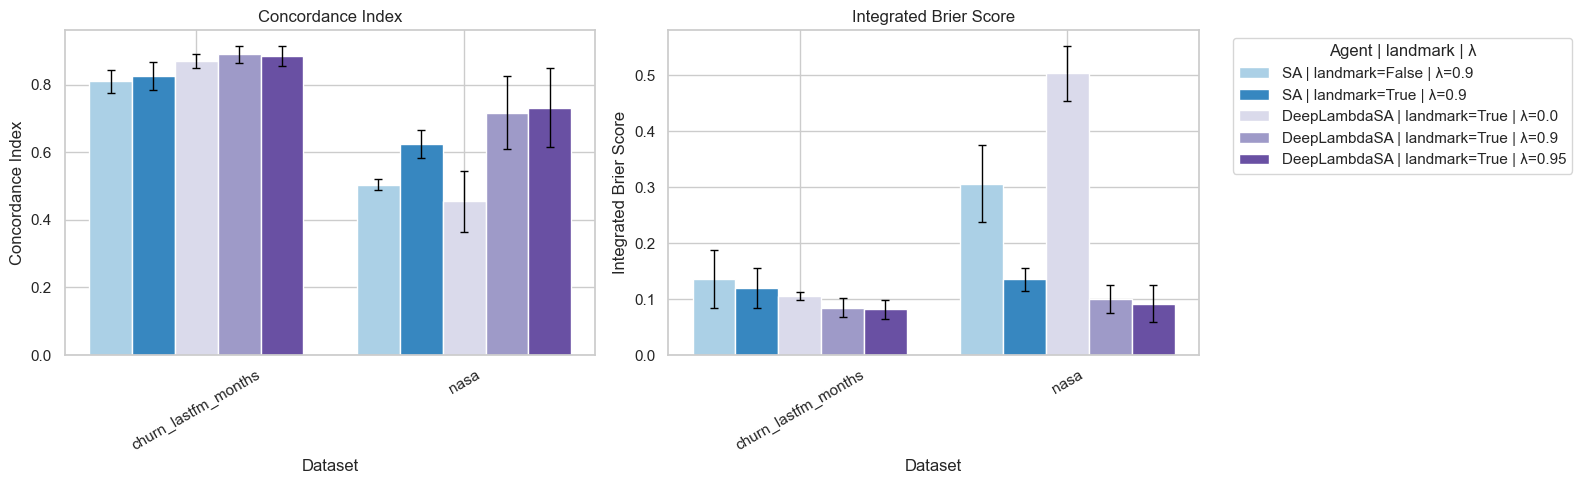

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

if not results_df.empty:
    group_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg_df = (
        results_df
        .groupby(group_cols)[['ci_new', 'ibs_new']]
        .agg(['mean', 'std'])
        .reset_index()
    )
    agg_df.columns = ['agent', 'dataset', 'landmark', 'lambda', 'ci_mean', 'ci_std', 'ibs_mean', 'ibs_std']
    agg_df = agg_df.sort_values(['agent', 'dataset', 'landmark', 'lambda']).reset_index(drop=True)
    agg_df['label'] = (
        agg_df['agent']
        + ' | landmark=' + agg_df['landmark'].astype(str)
        + ' | λ=' + agg_df['lambda'].astype(str)
    )

    datasets = sorted(agg_df['dataset'].unique())
    ordered_labels = []
    for agent in ['SA', 'LambdaSA', 'DeepLambdaSA']:
        agent_labels = agg_df.loc[agg_df['agent'] == agent, 'label'].unique().tolist()
        ordered_labels.extend(agent_labels)
    ordered_labels = [lbl for lbl in ordered_labels if lbl in agg_df['label'].unique()]

    label_colors = {}
    for agent, base_palette in {
        'SA': sns.color_palette('Blues', max(1, sum(lbl.startswith('SA') for lbl in ordered_labels))),
        'LambdaSA': sns.color_palette('Greens', max(1, sum(lbl.startswith('LambdaSA') for lbl in ordered_labels))),
        'DeepLambdaSA': sns.color_palette('Purples', max(1, sum(lbl.startswith('DeepLambdaSA') for lbl in ordered_labels))),
    }.items():
        agent_labels = [lbl for lbl in ordered_labels if lbl.startswith(agent)]
        for lbl, color in zip(agent_labels, base_palette):
            label_colors[lbl] = color

    x = np.arange(len(datasets))
    bar_groups = len(ordered_labels)
    total_width = 0.8
    bar_width = total_width / max(1, bar_groups)
    offsets = -total_width / 2 + bar_width / 2 + np.arange(bar_groups) * bar_width

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    metrics = [
        ('ci_mean', 'ci_std', 'Concordance Index', axes[0]),
        ('ibs_mean', 'ibs_std', 'Integrated Brier Score', axes[1]),
    ]

    for mean_col, std_col, title, ax in metrics:
        for idx, label in enumerate(ordered_labels):
            label_rows = agg_df[agg_df['label'] == label]
            label_means = label_rows.set_index('dataset')[mean_col]
            label_stds = label_rows.set_index('dataset')[std_col]
            heights = []
            errors = []
            positions = []
            for di, dataset in enumerate(datasets):
                if dataset in label_means.index:
                    heights.append(label_means.loc[dataset])
                    errors.append(label_stds.loc[dataset])
                    positions.append(x[di] + offsets[idx])
            if not heights:
                continue
            color = label_colors.get(label, 'gray')
            bars = ax.bar(positions, heights, bar_width, color=color, label=label)
            for bar, err in zip(bars, errors):
                if np.isnan(err):
                    continue
                ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                            yerr=err, fmt='none', ecolor='black', capsize=3, lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=30)
        ax.set_title(title)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(title)

    handles, labels = axes[0].get_legend_handles_labels()
    labeled = dict(zip(labels, handles))
    if labeled:
        axes[1].legend(labeled.values(), labeled.keys(), title='Agent | landmark | λ',
                       bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')


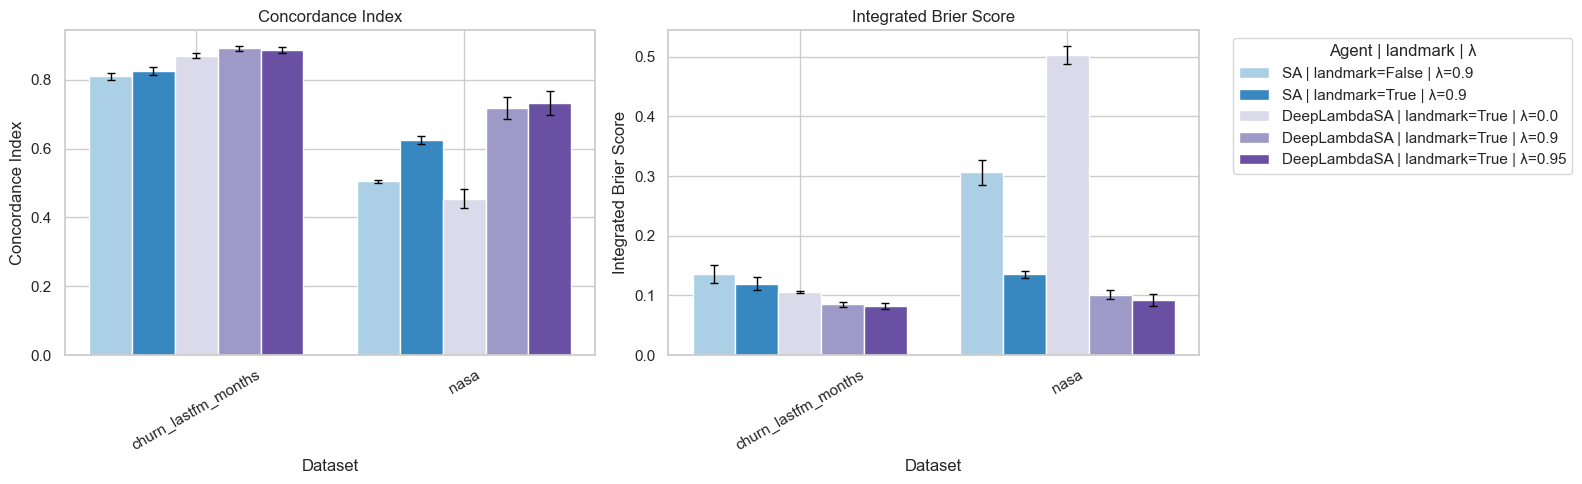

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

if not results_df.empty:
    group_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg_df = (
        results_df
        .groupby(group_cols)[['ci_new', 'ibs_new']]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    agg_df.columns = [
        'agent', 'dataset', 'landmark', 'lambda',
        'ci_mean', 'ci_std', 'ci_count',
        'ibs_mean', 'ibs_std', 'ibs_count'
    ]
    agg_df['ci_se'] = agg_df['ci_std'] / np.sqrt(agg_df['ci_count'].clip(lower=1))
    agg_df['ibs_se'] = agg_df['ibs_std'] / np.sqrt(agg_df['ibs_count'].clip(lower=1))

    agg_df = agg_df.sort_values(['agent', 'dataset', 'landmark', 'lambda']).reset_index(drop=True)
    agg_df['label'] = (
        agg_df['agent']
        + ' | landmark=' + agg_df['landmark'].astype(str)
        + ' | λ=' + agg_df['lambda'].astype(str)
    )

    datasets = sorted(agg_df['dataset'].unique())
    ordered_labels = []
    for agent in ['SA', 'LambdaSA', 'DeepLambdaSA']:
        agent_labels = agg_df.loc[agg_df['agent'] == agent, 'label'].unique().tolist()
        ordered_labels.extend(agent_labels)
    ordered_labels = [lbl for lbl in ordered_labels if lbl in agg_df['label'].unique()]

    label_colors = {}
    for agent, base_palette in {
        'SA': sns.color_palette('Blues', max(1, sum(lbl.startswith('SA') for lbl in ordered_labels))),
        'LambdaSA': sns.color_palette('Greens', max(1, sum(lbl.startswith('LambdaSA') for lbl in ordered_labels))),
        'DeepLambdaSA': sns.color_palette('Purples', max(1, sum(lbl.startswith('DeepLambdaSA') for lbl in ordered_labels))),
    }.items():
        agent_labels = [lbl for lbl in ordered_labels if lbl.startswith(agent)]
        for lbl, color in zip(agent_labels, base_palette):
            label_colors[lbl] = color

    x = np.arange(len(datasets))
    bar_groups = len(ordered_labels)
    total_width = 0.8
    bar_width = total_width / max(1, bar_groups)
    offsets = -total_width / 2 + bar_width / 2 + np.arange(bar_groups) * bar_width

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    metrics = [
        ('ci_mean', 'ci_se', 'Concordance Index', axes[0]),
        ('ibs_mean', 'ibs_se', 'Integrated Brier Score', axes[1]),
    ]

    for mean_col, se_col, title, ax in metrics:
        for idx, label in enumerate(ordered_labels):
            label_rows = agg_df[agg_df['label'] == label]
            means = label_rows.set_index('dataset')[mean_col]
            ses = label_rows.set_index('dataset')[se_col]
            heights = []
            errors = []
            positions = []
            for di, dataset in enumerate(datasets):
                if dataset in means.index:
                    heights.append(means.loc[dataset])
                    errors.append(ses.loc[dataset])
                    positions.append(x[di] + offsets[idx])
            if not heights:
                continue
            color = label_colors.get(label, 'gray')
            bars = ax.bar(positions, heights, bar_width, color=color, label=label)
            for bar, err in zip(bars, errors):
                if np.isnan(err) or err == 0.0:
                    continue
                ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                            yerr=err, fmt='none', ecolor='black', capsize=3, lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=30)
        ax.set_title(title)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(title)

    handles, labels = axes[0].get_legend_handles_labels()
    labeled = dict(zip(labels, handles))
    if labeled:
        axes[1].legend(labeled.values(), labeled.keys(), title='Agent | landmark | λ',
                       bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')
